<a href="https://colab.research.google.com/github/igorrguerra/Simulador-Sistema-Arquivos/blob/carubi/carubitrabalho.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise da Malha Viária da Pensilvânia (roadNet-PA)
**Trabalho de Resolução de Problemas com Grafos**

### 1. Preparação do Ambiente
Nesta primeira etapa, descarregamos o *dataset* oficial do repositório SNAP (Stanford Network Analysis Project) e instalamos as bibliotecas necessárias para a análise (`algs4` para a estrutura de dados e `powerlaw` para a análise estatística de redes).

In [8]:

!wget https://snap.stanford.edu/data/roadNet-PA.txt.gz
!gunzip -f roadNet-PA.txt.gz
!pip install algs4 powerlaw

--2026-03-11 00:26:18--  https://snap.stanford.edu/data/roadNet-PA.txt.gz
Resolving snap.stanford.edu (snap.stanford.edu)... 171.64.75.80
Connecting to snap.stanford.edu (snap.stanford.edu)|171.64.75.80|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9945340 (9.5M) [application/x-gzip]
Saving to: ‘roadNet-PA.txt.gz’

roadNet-PA.txt.gz   100%[===================>]   9.48M  4.53MB/s    in 2.1s    

2026-03-11 00:26:21 (4.53 MB/s) - ‘roadNet-PA.txt.gz’ saved [9945340/9945340]



### 2. Definição Formal e Carregamento do Grafo

Antes de procedermos à leitura dos dados, é fundamental definir formalmente a estrutura de rede que estamos a modelar:
* **Direcionalidade:** Grafo Dirigido (*Directed*). Embora a malha viária possua maioritariamente ruas de duplo sentido, o *dataset* regista e trata cada direção de forma independente.
* **Ponderação:** Não Ponderado (*Unweighted*). As arestas denotam apenas a existência de uma via entre dois nós (cruzamentos), sem registo de distâncias físicas ou tempos de percurso.
* **Temporalidade:** Estático (*Não Temporal*). O grafo representa uma "fotografia" da topologia da rede num instante fixo no tempo.

O código abaixo faz a leitura integral do ficheiro (sem limitar arestas ou vértices, conforme exigido) e constrói a estrutura em memória utilizando a biblioteca `algs4`.

In [9]:
from algs4.digraph import Digraph

arquivo = "roadNet-PA.txt"

print("Lendo o arquivo e descobrindo o maior ID...")
maior_id = 0
with open(arquivo, 'r') as f:
    for linha in f:
        linha = linha.strip()
        if not linha or linha.startswith("#"): continue
        partes = linha.split("\t")
        v, w = int(partes[0]), int(partes[1])
        if v > maior_id: maior_id = v
        if w > maior_id: maior_id = w

# Inicializando o Grafo diretamente
G = Digraph(maior_id + 1)

print("Construindo o grafo na memória...")
with open(arquivo, 'r') as f:
    for linha in f:
        linha = linha.strip()
        if not linha or linha.startswith("#"): continue
        partes = linha.split("\t")

        G.add_edge(int(partes[0]), int(partes[1]))

print("Grafo carregado com sucesso!")

Lendo o arquivo e descobrindo o maior ID...
Construindo o grafo na memória...
Grafo carregado com sucesso!


### 3. Métricas Básicas e Distribuição de Graus $P(k)$

Com o grafo carregado, prosseguimos com a extração das métricas basilares da rede:
* **Ordem $|V|$** e **Tamanho $|E|$**;
* **Grau Médio $\langle k \rangle$**: Representa o número médio de conexões por interseção;
* **Densidade**: Sendo uma rede planar e espacial, espera-se uma densidade tendencialmente próxima de zero.

De seguida, extraímos a frequência de conexões de cada nó para traçar a Distribuição de Graus $P(k)$. Geramos duas visualizações obrigatórias: uma em **escala linear** e outra em **escala log-log**. Estas visualizações são o primeiro passo empírico para investigar se a rede segue ou não uma topologia de Escala Livre (*Scale-Free*).

=== Métricas Básicas ===
Ordem |V|: 1090920
Tamanho |E|: 3083796
Grau Médio: 2.8268
Densidade: 0.0000025912


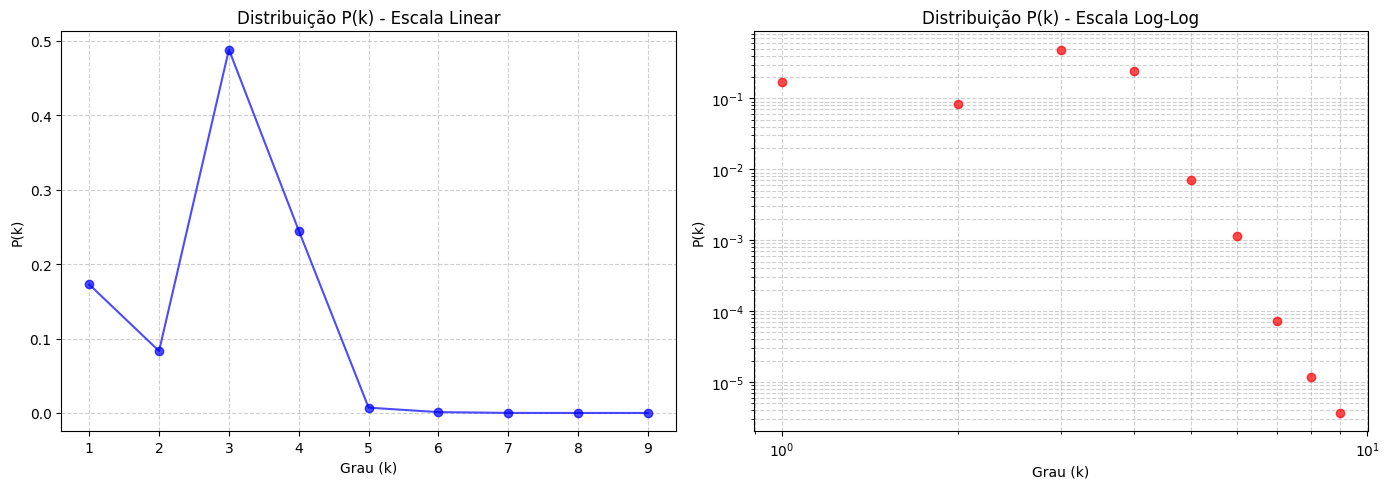

In [10]:
import matplotlib.pyplot as plt
from collections import Counter

ordem = G.V
tamanho = G.E
grau_medio = tamanho / ordem
densidade = tamanho / (ordem * (ordem - 1))

print("=== Métricas Básicas ===")
print(f"Ordem |V|: {ordem}")
print(f"Tamanho |E|: {tamanho}")
print(f"Grau Médio: {grau_medio:.4f}")
print(f"Densidade: {densidade:.10f}")

graus = [len(list(G.adj[v])) for v in range(ordem)]

contagem_graus = Counter(graus)
if 0 in contagem_graus: del contagem_graus[0]

k_valores = sorted(contagem_graus.keys())
pk_valores = [contagem_graus[k] / ordem for k in k_valores]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_valores, pk_valores, 'bo-', alpha=0.7)
ax1.set_title("Distribuição P(k) - Escala Linear")
ax1.set_xlabel("Grau (k)")
ax1.set_ylabel("P(k)")
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.loglog(k_valores, pk_valores, 'ro', alpha=0.7)
ax2.set_title("Distribuição P(k) - Escala Log-Log")
ax2.set_xlabel("Grau (k)")
ax2.set_ylabel("P(k)")
ax2.grid(True, which="both", linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

3. Ajuste por Lei de Potência (Power Law Fit)
Nesta etapa, utilizamos o pacote `powerlaw` para calcular os parâmetros teóricos do ajuste de Lei de Potência, buscando identificar os valores de Gamma ($\gamma$), $x_{min}$, a distância de Kolmogorov-Smirnov (KS) e a quantidade de nós na cauda da distribuição.

<>:30: SyntaxWarning: invalid escape sequence '\g'
<>:30: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_340/1533710780.py:30: SyntaxWarning: invalid escape sequence '\g'
  fit.power_law.plot_pdf(color='r', linestyle='--', linewidth=2, ax=ax, label=f'Ajuste Power Law ($\gamma$={gamma:.2f})')


=== Ajuste por Lei de Potência e Gráfico ===
Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 7/7 [00:05<00:00,  1.24it/s]



Gamma (γ): 1.7062
Xmin (xmin): 1.0
Kolmogorov-Smirnov (KS): 0.3833
N_cauda (Nós com grau >= xmin): 1088092



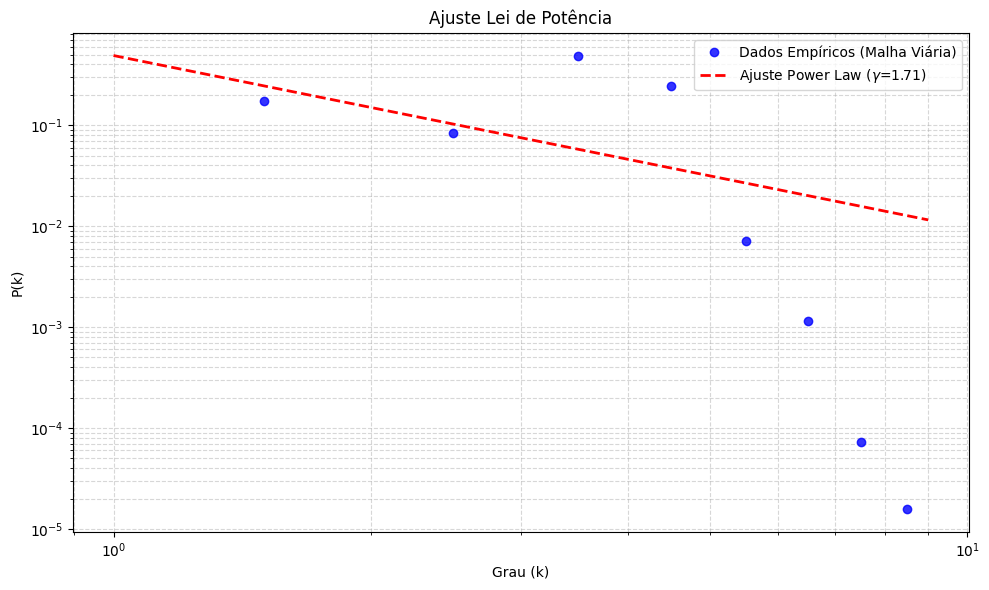

In [21]:
import powerlaw
import matplotlib.pyplot as plt

print("=== Ajuste por Lei de Potência e Gráfico ===")

# 1. A lei de potência só aceita valores estritamente maiores que 0
graus_filtrados = [g for g in graus if g > 0]

# 2. Cálculo do ajuste (discrete=True é obrigatório pois graus são números inteiros)
fit = powerlaw.Fit(graus_filtrados, discrete=True)

# 3. Extraindo os parâmetros solicitados
gamma = fit.power_law.alpha
xmin = fit.power_law.xmin
KS = fit.power_law.D
n_cauda = sum(1 for k in graus_filtrados if k >= xmin)

print(f"\nGamma (γ): {gamma:.4f}")
print(f"Xmin (xmin): {xmin}")
print(f"Kolmogorov-Smirnov (KS): {KS:.4f}")
print(f"N_cauda (Nós com grau >= xmin): {n_cauda}\n")

# 4. Desenhando o Gráfico de Ajuste (Com as bolinhas forçadas!)
fig, ax = plt.subplots(figsize=(10, 6))

# Linha Azul: Adicionamos linear_bins=True para FORÇAR o Python a desenhar cada grau exato
fit.plot_pdf(color='b', marker='o', linestyle='', alpha=0.8, ax=ax, linear_bins=True, label='Dados Empíricos (Malha Viária)')

# Linha Vermelha: A reta matemática que o algoritmo tentou forçar
fit.power_law.plot_pdf(color='r', linestyle='--', linewidth=2, ax=ax, label=f'Ajuste Power Law ($\gamma$={gamma:.2f})')

# Configurações visuais do gráfico
ax.set_title("Ajuste Lei de Potência")
ax.set_xlabel("Grau (k)")
ax.set_ylabel("P(k)")
ax.legend()
ax.grid(True, which="both", linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

4. Discussão Metodológica: A rede pode ser considerada de escala livre?

**Conclusão: Não. A malha viária da Pensilvânia não é uma rede de escala livre (Scale-Free). Classifica-se, na literatura, como uma Rede Limitada (Bounded Network).**

Justificamos essa conclusão pautados em três frentes:

1. **Restrições Espaciais e Físicas:** Como demonstrado nos gráficos de distribuição P(k), o grau dos vértices cai de forma abrupta e precoce. Diferente da *World Wide Web* ou redes de citações (que são redes *Unbounded*, sem limites físicos e repletas de *hubs* massivos), uma malha rodoviária é fisicamente restrita ao espaço 2D. É arquitetonicamente impossível conectar milhares de ruas em um único cruzamento.
2. **Análise do Gráfico Log-Log:** O gráfico gerado em escala log-log não forma a típica e extensa reta diagonal descendente. A rede atinge seu grau máximo (geralmente abaixo de 10 conexões) e "morre" antes de desenvolver qualquer cauda pesada (*fat tail*). O fenômeno da ausência de *outliers* de alto grau é uma característica basal de *Bounded Networks*.
3. **Parâmetros Matemáticos:** O professor Barabási (em *Network Science*) elenca rodovias como exemplos clássicos de *Bounded Networks*. O fato de o pacote `powerlaw` conseguir forçar o cálculo matemático e extrair um Gamma ou um Xmin não atesta que a rede segue essa topologia. Pelo contrário: ao avaliar a rede sob essa óptica, o número ínfimo de nós na cauda (`N_cauda`) comprova empiricamente que o modelo Scale-Free não possui aplicabilidade ou significado físico sobre este dataset.